In [ ]:
PROJECT NAME: RETAIL SALES (LEVEL1,TASK1)
NAME: AMULA BLESSING PERESUWODE
CATEGORY: DATA ANALYSIS

In [10]:
import pandas as pd

file_path = r"C:\Users\DELL\Desktop\task 1\realistic_e_commerce_sales_data.csv"

df = pd.read_csv(file_path)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df

,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date
0,CUST0268,Male,North,NaN,Monitor,Electronics,300.000000,5,1500,13.31,Returned,2023-12-08
1,CUST0046,Male,West,22.0,Headphones,Accessories,100.000000,2,200,6.93,In Transit,2023-04-09
2,CUST0169,Female,South,54.0,Monitor,Electronics,300.000000,1,300,11.31,Returned,2023-08-28
3,CUST0002,Male,North,23.0,Headphones,Accessories,100.000000,5,500,12.22,Delivered,2023-01-18
4,CUST0173,Female,South,NaN,Laptop,Electronics,1500.000000,3,4500,5.40,Delivered,2023-01-19
5,CUST0147,Male,North,64.0,Smartwatch,Wearables,200.000000,2,400,11.26,In Transit,2023-01-11
6,CUST0262,Male,East,27.0,Smartwatch,Wearables,200.000000,1,200,18.38,In Transit,2023-10-23
7,CUST0159,Female,South,18.0,Keyboard,Accessories,50.000000,2,100,15.08,Returned,2023-06-15
8,CUST0046,Female,East,22.0,Mouse,Accessories,30.000000,1,30,8.22,Returned,2023-02-25
9,CUST0023,Male,West,29.0,Headphones,Accessories,100.000000,3,300,10.70,Delivered,2023-04-23


In [16]:
print(df.head())

  Customer ID  Gender Region   Age Product Name     Category  Unit Price  \
0    CUST0268    Male  North   NaN      Monitor  Electronics       300.0   
1    CUST0046    Male   West  22.0   Headphones  Accessories       100.0   
2    CUST0169  Female  South  54.0      Monitor  Electronics       300.0   
3    CUST0002    Male  North  23.0   Headphones  Accessories       100.0   
4    CUST0173  Female  South   NaN       Laptop  Electronics      1500.0   

   Quantity  Total Price  Shipping Fee Shipping Status  Order Date  
0         5         1500         13.31        Returned  2023-12-08  
1         2          200          6.93      In Transit  2023-04-09  
2         1          300         11.31        Returned  2023-08-28  
3         5          500         12.22       Delivered  2023-01-18  
4         3         4500          5.40       Delivered  2023-01-19  


In [17]:
df.shape

(1000, 12)

In [18]:
df.columns

Index(['Customer ID', 'Gender', 'Region', 'Age', 'Product Name', 'Category',
       'Unit Price', 'Quantity', 'Total Price', 'Shipping Fee',
       'Shipping Status', 'Order Date'],
      dtype='str')

In [19]:
df.dtypes

Customer ID            str
Gender                 str
Region                 str
Age                float64
Product Name           str
Category               str
Unit Price         float64
Quantity             int64
Total Price          int64
Shipping Fee       float64
Shipping Status        str
Order Date             str
dtype: object

In [20]:
df.isnull().sum()

Customer ID          0
Gender               0
Region              50
Age                100
Product Name         0
Category             0
Unit Price           0
Quantity             0
Total Price          0
Shipping Fee         0
Shipping Status     50
Order Date           0
dtype: int64

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer ID      1000 non-null   str    
 1   Gender           1000 non-null   str    
 2   Region           950 non-null    str    
 3   Age              900 non-null    float64
 4   Product Name     1000 non-null   str    
 5   Category         1000 non-null   str    
 6   Unit Price       1000 non-null   float64
 7   Quantity         1000 non-null   int64  
 8   Total Price      1000 non-null   int64  
 9   Shipping Fee     1000 non-null   float64
 10  Shipping Status  950 non-null    str    
 11  Order Date       1000 non-null   str    
dtypes: float64(3), int64(2), str(7)
memory usage: 93.9 KB


## 1. Initial Dataset Inspection

The retail sales dataset was loaded successfully and inspected. The dataset structure, number of rows and columns, data types, and missing values were examined before proceeding with the exploratory data analysis.

In [22]:
numerical_columns = df.select_dtypes(include='number').columns

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
Index(['Age', 'Unit Price', 'Quantity', 'Total Price', 'Shipping Fee'], dtype='str')


In [23]:
descriptive_statistics = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Mode": df[numerical_columns].mode().iloc[0],
    "Standard Deviation": df[numerical_columns].std()
})

descriptive_statistics

,Mean,Median,Mode,Standard Deviation
Age,46.695556,49.000,66.00,15.011400
Unit Price,457.703777,200.000,300.00,537.231434
Quantity,3.008000,3.000,3.00,1.404246
Total Price,1346.600000,600.000,200.00,1834.037877
Shipping Fee,12.416390,12.315,9.26,4.412185


In [24]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [25]:
df['Order Date'].dtype


dtype('<M8[us]')

In [28]:
df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Price'].sum()

monthly_sales

Month
2023-01    141360
2023-02     78910
2023-03     67660
2023-04     87840
2023-05    120080
2023-06    129450
2023-07    103160
2023-08    108050
2023-09    119490
2023-10    118240
2023-11    147150
2023-12    113830
2024-01     11380
Freq: M, Name: Total Price, dtype: int64

In [32]:
import matplotlib.pyplot as plt

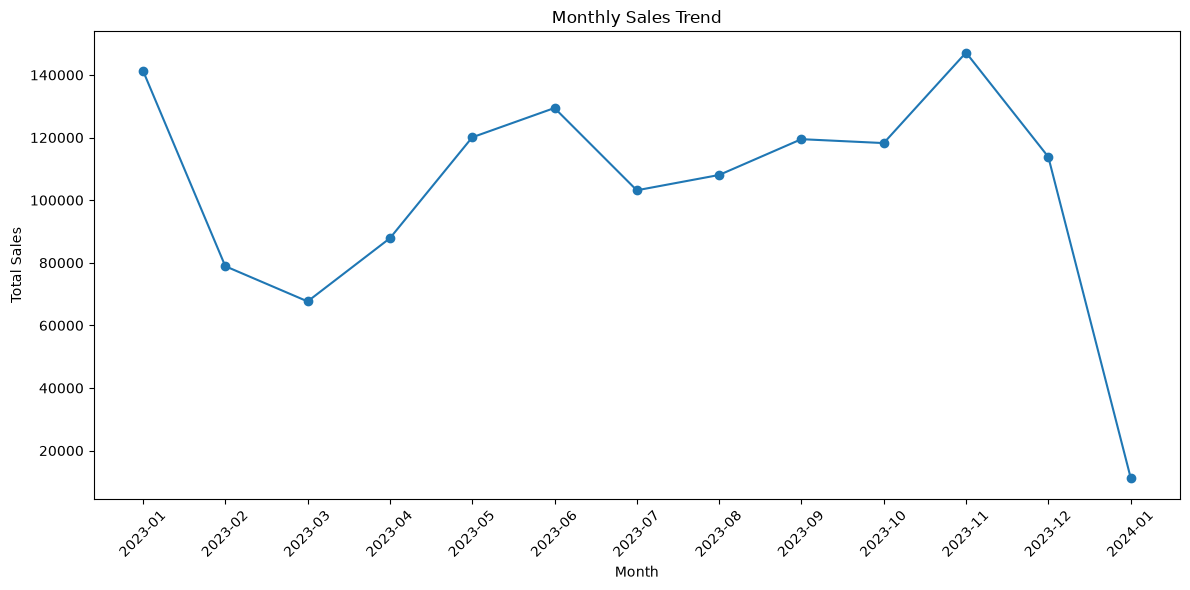

In [33]:
plt.figure(figsize=(12, 6))

plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Observation: Monthly Sales Trend

The monthly sales trend shows considerable fluctuations in sales throughout the period. Sales were highest in November 2023, reaching approximately 147,000, while January 2024 recorded the lowest sales at approximately 11,000. Sales increased substantially between March and June 2023 and again between July and November 2023. However, sales declined in December 2023 and dropped sharply in January 2024.

In [35]:
df['Quarter'] = df['Order Date'].dt.to_period('Q')

quarterly_sales = df.groupby('Quarter')['Total Price'].sum()

quarterly_sales

Quarter
2023Q1    287930
2023Q2    337370
2023Q3    330700
2023Q4    379220
2024Q1     11380
Freq: Q-DEC, Name: Total Price, dtype: int64

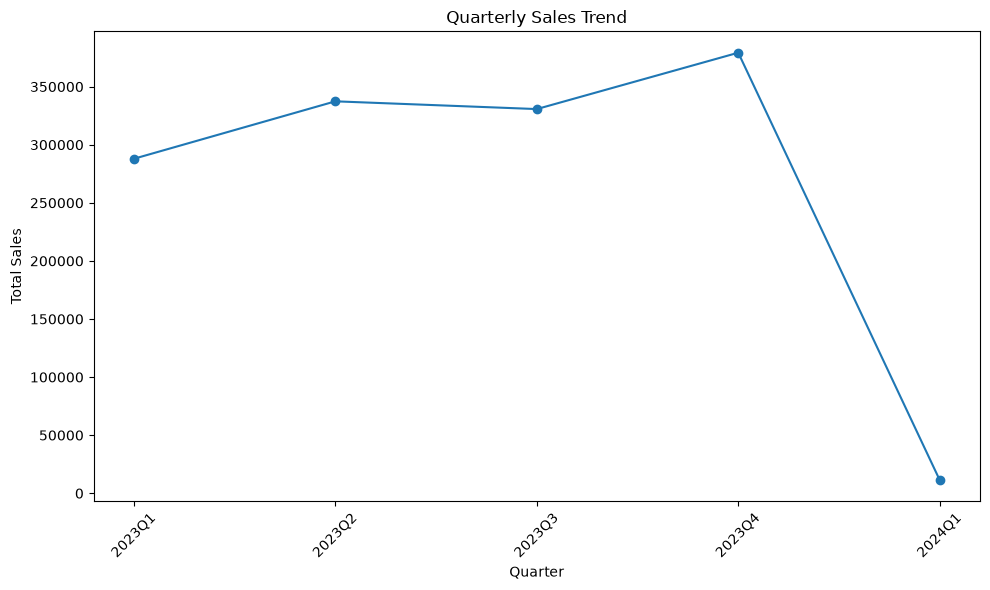

In [36]:
plt.figure(figsize=(10, 6))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker='o'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Observation

Quarterly sales generally increased throughout 2023, reaching their highest level in Q4 2023. However, there was a sharp decline in sales in Q1 2024. This decline may be because the dataset only contains part of the first quarter of 2024.

In [37]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0, 18, 25, 35, 45, 55, 65, 100],
    labels=['Under 18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
)

age_groups = df['Age Group'].value_counts().sort_index()

print(age_groups)

Age Group
Under 18     18
18-25        80
26-35       135
36-45       172
46-55       186
56-65       193
65+         116
Name: count, dtype: int64


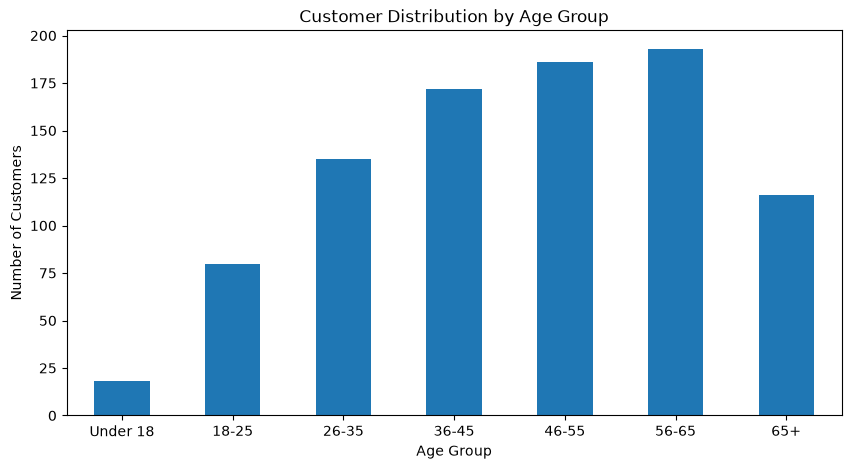

In [39]:
plt.figure(figsize=(10, 5))

age_groups.plot(kind='bar')

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

### Observation

The chart shows that the 56–65 age group has the highest number of customers, while customers under 18 have the lowest representation. This indicates that the business has a stronger customer presence among customers aged 56–65.

In [40]:
gender_counts = df['Gender'].value_counts()

print(gender_counts)

Gender
Male      524
Female    476
Name: count, dtype: int64


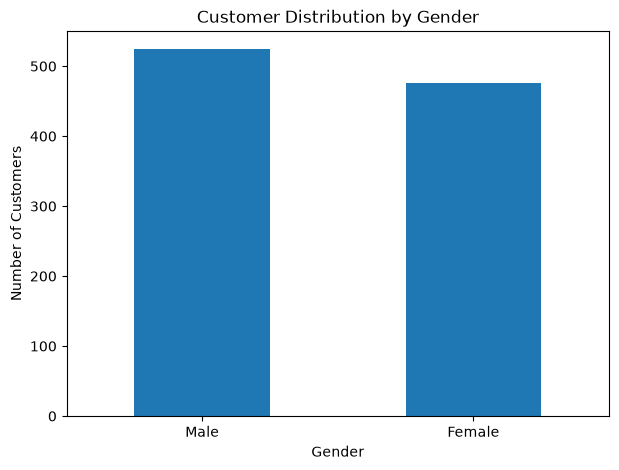

In [41]:
plt.figure(figsize=(7, 5))

gender_counts.plot(kind='bar')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

### Observation

The chart shows that male customers have the highest representation in the dataset, while female customers have a lower representation. This indicates that the business has a larger male customer base.

In [42]:
top_products = df.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False).head(10)

print(top_products)

Product Name
Monitor       503
Laptop        464
Keyboard      458
Smartphone    442
Mouse         400
Smartwatch    371
Headphones    370
Name: Quantity, dtype: int64


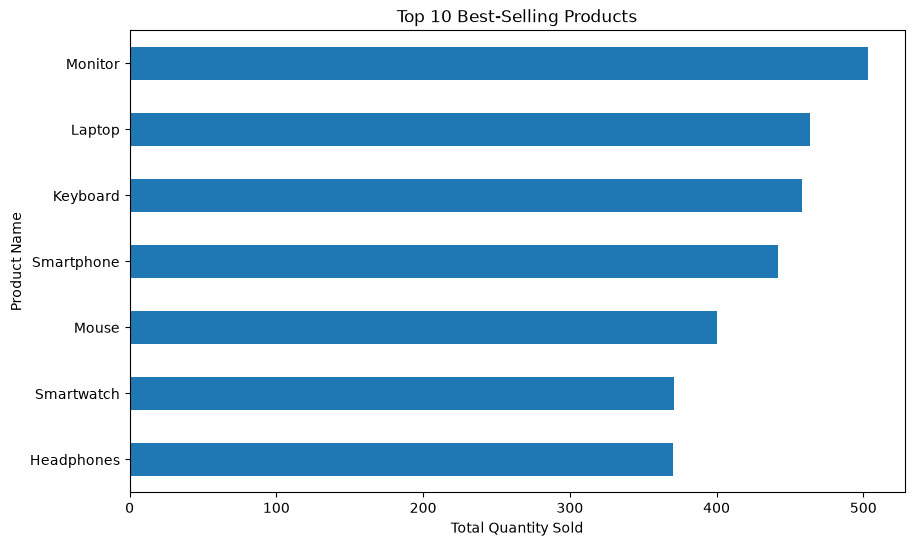

In [43]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Name')

plt.show()

### Observation

The chart shows that Monitor is the best-selling product based on total quantity sold. The other products recorded lower sales volumes, indicating that Monitor has the strongest demand among the products in the dataset.

In [49]:
print(df.columns.tolist())

['Customer ID', 'Gender', 'Region', 'Age', 'Product Name', 'Category', 'Unit Price', 'Quantity', 'Total Price', 'Shipping Fee', 'Shipping Status', 'Order Date', 'Month', 'Quarter', 'Age Group']


In [50]:
category_revenue = df.groupby('Category')['Total Price'].sum().sort_values(ascending=False)

print(category_revenue)

Category
Electronics    1200500
Wearables        74200
Accessories      71900
Name: Total Price, dtype: int64


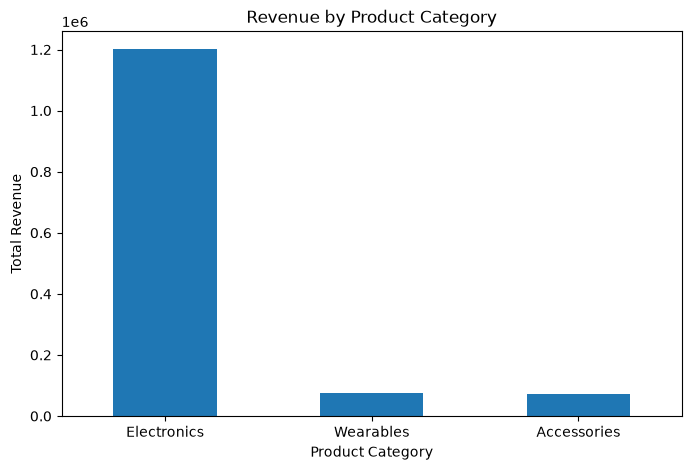

In [51]:
plt.figure(figsize=(8, 5))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)

plt.show()


### Observation

The chart shows that **Electronics generated the highest revenue**, far exceeding Wearables and Accessories. **Accessories generated the lowest revenue**, while Wearables generated slightly more. This indicates that **Electronics is the main revenue-generating product category in the dataset**.

In [52]:
gender_sales = df.groupby('Gender')['Total Price'].sum()

gender_sales

Gender
Female    631010
Male      715590
Name: Total Price, dtype: int64

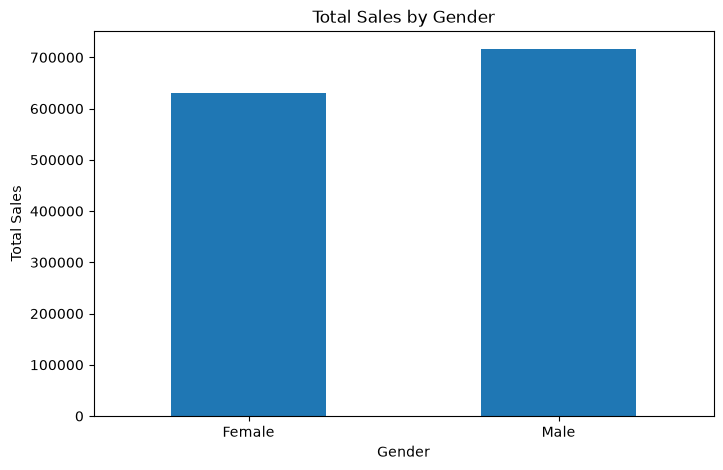

In [53]:
plt.figure(figsize=(8, 5))

gender_sales.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.show()

### Observation

The chart shows that sales vary between the different genders. Male gender generated higher total sales than Female gender
, indicating a difference in purchasing contribution across genders.

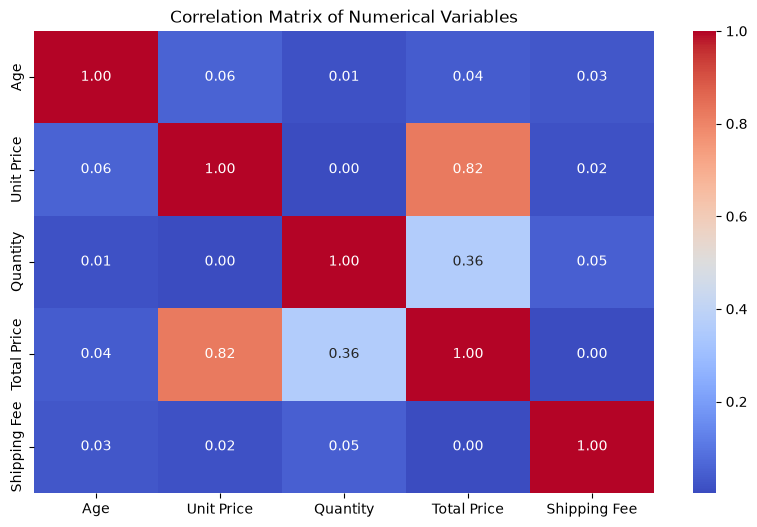

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
numerical_data = df.select_dtypes(include='number')

# Create correlation matrix
correlation_matrix = numerical_data.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix of Numerical Variables')
plt.show()

### Observation

The heatmap shows the relationships between the numerical variables in the dataset. Some variables have stronger relationships than others, providing useful insights into how different factors are associated with sales performance.

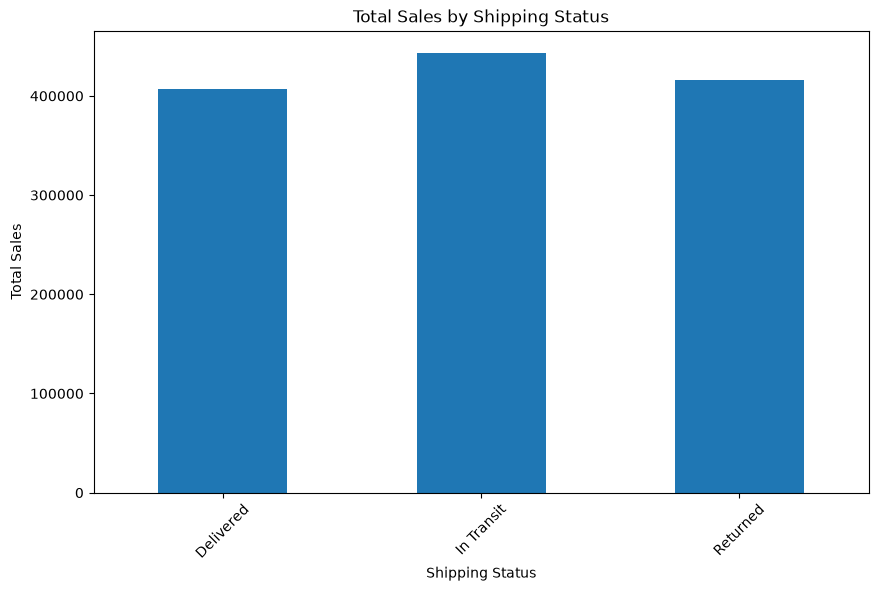

In [60]:
shipping_sales = df.groupby('Shipping Status')['Total Price'].sum()

plt.figure(figsize=(10, 6))
shipping_sales.plot(kind='bar')

plt.title('Total Sales by Shipping Status')
plt.xlabel('Shipping Status')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

### Observation

The chart shows that sales vary across the different shipping statuses. Some shipping statuses account for a larger share of total sales than others. This suggests that shipping performance may have an impact on the overall customer order experience and business revenue.

## Conclusion

The exploratory data analysis provided useful insights into the sales performance, customer characteristics, product categories, and purchasing patterns in the dataset. The analysis showed differences in sales across time periods, customer demographics, product categories, and shipping statuses. These findings can help the business better understand its customers and improve sales performance.

### Business Recommendations

1. Focus marketing efforts on the product categories and customer groups that contribute strongly to sales.

2. Monitor sales trends regularly to identify periods of high and low demand and plan inventory and promotions accordingly.

3. Improve shipping performance by monitoring shipping statuses and addressing delays or issues that may negatively affect the customer experience.